### Preliminary analysis of the GRI

Using standard models for survival analysis with competing risks such Cause specific Cox PH and Fine and Grey. 

We will run it over two datasets, one would be the subset of qpis (quality measures for colorectal cancer), 
and secondly over the whole clinical data, where there are potential predictors. The dataset has been preprocessed in "prpeprocess-1.ipynb", where expert knowledge from Joanne Edwards' lab was considered to substract the relevant columns and rows, plus any further decisions taken. 

Hopefully the second dataset would allow give us hints of future qpis. 

Regarding missing values, they need to be imputed... the continuous values standarized, etc. 

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import math

# sksurv
from sksurv.util import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis

# scikit-learn
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer
from sklearn.base import clone

# cmprsk (contains Fine and Grey model) it is and python 
# wrapper of R functions. Dependencies such r-survival are also downloaded
# Requires rpy2 librar
import rpy2

# my functions 

from helper import fit_cs_cox_manual
from helper import cifs_from_cs_hazards
from helper import fit_preprocessor

from metrics.score import CompRiskMetricsCompute
# hazardous
from metrics.score import IncidenceScoreComputer
from metrics.score import KaplanMeierIPCW


# Iterative inputer (for mice)
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import VarianceThreshold 
from sklearn.ensemble import ExtraTreesRegressor

# lifelines
from lifelines import CoxPHFitter

pd.set_option("display.max_columns", None)



### 5-fold cross-validation


We can use MICE for imputation

In [227]:
## prepare the data

gri = pd.read_csv("data/GRI_preprocess-1.csv", index_col="TMA_order")
print(gri.shape)
# define time and status
time, status = "DFS_months_2020", "Cmprsk_Status"

print(gri[[time, status]].isna().sum())

# drop if we do not know any of these two:
df = gri.dropna(subset=[time, status])

print(df.shape)
# create surv object 
#y = Surv.from_dataframe(time, status, df) # does not work because it expects binary
#y = Surv.from_dataframe(time, event = status > 0) 

X = df.drop(columns=[time, status, "Unnamed: 0", "Recurrence_local1_distant2", "Colin_full_recurrence_sites", "Dukes"])
T_all = df[time].astype(float).to_numpy()
D_all = df[status].astype(int).to_numpy()



(724, 87)
DFS_months_2020    21
Cmprsk_Status       2
dtype: int64
(702, 87)


In [228]:
X.dtypes
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 702 entries, 1 to 786
Data columns (total 81 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   c0r1                    702 non-null    bool   
 1   MMR_Status_Jen          683 non-null    float64
 2   adj1                    701 non-null    object 
 3   el0em1                  702 non-null    bool   
 4   age                     702 non-null    float64
 5   sex                     702 non-null    bool   
 6   Right0_Left1            702 non-null    bool   
 7   Location                702 non-null    int64  
 8   tstage                  702 non-null    int64  
 9   nstage                  702 non-null    int64  
 10  mstage                  702 non-null    bool   
 11  Differentiation         697 non-null    object 
 12  Tumour_budding          681 non-null    object 
 13  TuPerf                  702 non-null    bool   
 14  MargInv                 702 non-null    bool   

We can use the pipe to introduce preprocessing with mice and scaling. 

In [229]:
def modelling_pipe(model):
    # select the numeric
    num_sel = make_column_selector(dtype_include=np.number)
    # select the categorical
    cat_sel = make_column_selector(dtype_include=["object", "category", "string", "bool"])

    num = Pipeline([
        # Using the equivalent to Mice in R
        ("mice", IterativeImputer(random_state=42, sample_posterior=True, max_iter=10, initial_strategy="median")),
        ("scaler", StandardScaler()),
        ])
    cat = Pipeline([
        # since it is categorical we impute with the most frequent
        ("mode", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore"))
    ])
    prep = ColumnTransformer([
        ("num", num, num_sel),
        ("cat", cat, cat_sel)],
        remainder="drop")
    
    return Pipeline([("prep", prep),("model", model)])
    

We can use a stratified 5cv fold so that we preserve the proportions of causes by fold. 

In [230]:
# init object cv
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(cv.get_n_splits())  


5


In [231]:
# generate the splits based on the causes D
splits = list(cv.split(np.arange(len(df)), y=D_all))
len(splits[0][0]) 


561

Each fold having similar proportions of causes, as well as train and sets

In [232]:
for fold, (train_idx, val_idx) in enumerate(splits, 1):
    print(f"Fold number: {fold}")
    print(f"Length of training set: {len(train_idx)}")
    print(f"Length of test set: {len(val_idx)}")

    vals, counts = np.unique(D_all[train_idx], return_counts=True)
    pct = counts / counts.sum() * 100

    print(f"Training set proportion of each cause: {pct}")

    vals, counts = np.unique(D_all[val_idx], return_counts=True)
    pct = counts / counts.sum() * 100

    print(f"Test set proportion of each cause: {pct}")


Fold number: 1
Length of training set: 561
Length of test set: 141
Training set proportion of each cause: [32.97682709 31.90730838 35.11586453]
Test set proportion of each cause: [33.33333333 31.20567376 35.46099291]
Fold number: 2
Length of training set: 561
Length of test set: 141
Training set proportion of each cause: [32.97682709 31.90730838 35.11586453]
Test set proportion of each cause: [33.33333333 31.20567376 35.46099291]
Fold number: 3
Length of training set: 562
Length of test set: 140
Training set proportion of each cause: [33.09608541 31.67259786 35.23131673]
Test set proportion of each cause: [32.85714286 32.14285714 35.        ]
Fold number: 4
Length of training set: 562
Length of test set: 140
Training set proportion of each cause: [33.09608541 31.67259786 35.23131673]
Test set proportion of each cause: [32.85714286 32.14285714 35.        ]
Fold number: 5
Length of training set: 562
Length of test set: 140
Training set proportion of each cause: [33.09608541 31.67259786 3

Train a Fine and Grey model, and a cause specific cox proportional hazards. 

- The cause-specific cox proportional hazards fits a separate cox PH to each cause, and therefore it treats the events from other causes as censored. We know that it would overestimate the incidence of the events. 
- The Fine and Grey model, or subdistribution hazards, where the cumulative incidence is associated with the subdistribution hazard. Here the competing risk events are treated differently, by a weigth estimated as if there had informative censoring. It also assumes a PH form. 

https://pmc.ncbi.nlm.nih.gov/articles/PMC5326634/#:~:text=Cause%2Dspecific%20hazard%20regression%20model%20can%20be%20fit%20with%20Cox,with%20COX%20proportional%20hazard%20regression.

We could use the pipe, but the problem is that the majority of models might not come from sklearn, and wrappers might be constantly needed. 

In [233]:
for fold, (train_idx, val_idx) in enumerate(splits, 1):
    # subsetting
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    t_train, t_val = T_all[train_idx], T_all[val_idx]
    d_train, d_val = D_all[train_idx], D_all[val_idx]

    #print(np.max(t_train))
    
    # time grid for evaluation purposes
    time_grid = np.arange(0, np.max(t_train), 0.1)
    #print(len(time_grid))

    cause_1 = (d_train == 1)
    pipe_trm = modelling_pipe(CoxPHSurvivalAnalysis(alpha=1.0))
    pipe_trm.fit(X_train, Surv.from_arrays(event=cause_1, time=t_train))
    ## something like this
    ## calculate cumhaz on the time grid... 


Trying with manual helper function that do something similar to the pipes


In [235]:

ibs_c1_folds = []
ibs_c2_folds = []

ibs_c1_folds_hz = []
ibs_c2_folds_hz = []

def chf_to_matrix(chf_list, tgrid):
    n = len(chf_list)
    m = len(tgrid)
    out = np.empty((n, m), float)
    for i, f in enumerate(chf_list):
        out[i] = f(tgrid)        # evaluate cumulative hazard at all times
    return out

for fold, (train_idx, val_idx) in enumerate(splits, 1):
    # 1) subsetting
    print("Fold:", fold)
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    t_train, t_val = T_all[train_idx], T_all[val_idx]
    d_train, d_val = D_all[train_idx], D_all[val_idx]

    #print(np.max(t_train))
    
    # 2) time grid for evaluation purposes
    time_grid = np.arange(0, np.max(t_train), 0.1)
    
    # 3) inpute and scale on TRAIN
    print("Processing with impute/scaling/one_hot encoding on TRAIN:")
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()    
    cat_cols = X_train.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

    #mice gives some warning, probably because small sample size vs covariates
    #mice = IterativeImputer(random_state=42, sample_posterior=True,
    #                        max_iter=10, initial_strategy="median")

    mice = IterativeImputer(
        random_state=42,
        max_iter=20,           
        tol=1e-3, 
        sample_posterior=False,
        initial_strategy="median",
    )
    # maybe try the ExtraTreesRegressor or the KNN ?
    Xn_imp = mice.fit_transform(X_train[num_cols]) if num_cols else np.empty((len(X_train), 0))

    scaler = StandardScaler()
    Xn = scaler.fit_transform(Xn_imp) if num_cols else np.empty((len(X_train), 0))

    cat_imp = SimpleImputer(strategy="most_frequent")
    Xc_imp = cat_imp.fit_transform(X_train[cat_cols]) if cat_cols else np.empty((len(X_train), 0))

    try:
        ohe = OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", drop=None, sparse=False)
    Xc = ohe.fit_transform(Xc_imp) if cat_cols else np.empty((len(X_train), 0))

    print("Xn:", type(Xn), getattr(Xn, "shape", None), "ndim=", getattr(Xn, "ndim", None))
    print("Xc:", type(Xc), getattr(Xc, "shape", None), "ndim=", getattr(Xc, "ndim", None))

    # combine & remove constant columns
    X_comb = np.hstack([Xn, Xc]) if (Xn.size or Xc.size) else np.empty((len(X_train), 0))
    nzv = VarianceThreshold(threshold=0.0)
    Xnz = nzv.fit_transform(X_comb) if X_comb.size else X_comb

    print("Xnz:", type(Xnz), getattr(Xnz, "shape", None), "ndim=", getattr(Xnz, "ndim", None))
    
    # 4) inpute and scale on TEST
    print("Processing with impute/scaling/one_hot encoding on TEST:")
    num_cols = X_val.select_dtypes(include=[np.number]).columns.tolist()    
    cat_cols = X_val.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

    # numeric
    if num_cols:
        Xn_val_imp = mice.transform(X_val[num_cols])
        Xn_val = scaler.transform(Xn_val_imp)
    else:
        Xn_val = np.empty((len(X_val), 0))

    # categorical
    if cat_cols:
        Xc_val_imp = cat_imp.transform(X_val[cat_cols])
        Xc_val = ohe.transform(Xc_val_imp)  # dense because sparse_output=False
    else:
        Xc_val = np.empty((len(X_val), 0))

    print("Xn:", type(Xn_val), getattr(Xn_val, "shape", None), "ndim=", getattr(Xn_val, "ndim", None))
    print("Xc:", type(Xc_val), getattr(Xc_val, "shape", None), "ndim=", getattr(Xc_val, "ndim", None))

    # combine and apply same NZV mask
    X_comb_val = np.hstack([Xn_val, Xc_val]) if (Xn_val.size or Xc_val.size) else np.empty((len(X_val), 0))
    Xnz_val = nzv.transform(X_comb_val) if X_comb_val.size else X_comb_val

    print("Xnz:", type(Xnz_val), getattr(Xnz_val, "shape", None), "ndim=", getattr(Xnz_val, "ndim", None))

    # 5) Fit model 
    y_c1 = Surv.from_arrays(event=(d_train == 1), time=t_train)
    y_c2 = Surv.from_arrays(event=(d_train == 2), time=t_train)

    # adding alpha as regularizer for ridge regression penalty
    cox_1 = CoxPHSurvivalAnalysis(alpha=1).fit(Xnz, y_c1)
    cox_2 = CoxPHSurvivalAnalysis(alpha=1).fit(Xnz, y_c2)

    # 6) Estimate the cumulative hazard
    m = len(time_grid)
    A1 = cox_1.predict_cumulative_hazard_function(Xnz_val)
    A2 = cox_2.predict_cumulative_hazard_function(Xnz_val)


    # 7) Calculate G_t
    metrics = CompRiskMetricsCompute(
        time_grid=time_grid,
        durations_train=t_train,
        delta_train=d_train,
        eps=0.01
    )
    # To avoid weights blowing up:
    mask = metrics.G_t >= 0.05
    time_grid = time_grid[mask]

    # re-init with trimmed grid
    metrics = CompRiskMetricsCompute(time_grid=time_grid, 
                                     durations_train=t_train, 
                                     delta_train=d_train, 
                                     eps=0.01)
    
    # make it as matrix
    A1_mat = chf_to_matrix(A1, time_grid)   # shape (n_val, m)
    A2_mat = chf_to_matrix(A2, time_grid)

    # 8) Calculate the CIFs from the hazards
    F1_pred, F2_pred = cifs_from_cs_hazards(A1_mat, A2_mat)

    # 9) Calculate the metrics
    ibs_c1 = metrics.integrated_brier_cif(F1_pred, t_val, d_val, cause=1)
    ibs_c2 = metrics.integrated_brier_cif(F2_pred, t_val, d_val, cause=2)

    ibs_c1_folds.append(float(ibs_c1))
    ibs_c2_folds.append(float(ibs_c2))
    print(f"Fold {fold} (Manual): IBS(cause1)={ibs_c1:.4f} | IBS(cause2)={ibs_c2:.4f}")


    #### Alternatively from hazardous
    y_train = dict(event=d_train, duration=t_train)
    y_val   = dict(event=d_val,   duration=t_val)  

    # adding alpha as regularizer for ridge regression penalty
    cox_1 = CoxPHSurvivalAnalysis(alpha=1).fit(Xnz, y_c1)
    cox_2 = CoxPHSurvivalAnalysis(alpha=1).fit(Xnz, y_c2)

    # 6) Estimate the cumulative hazard
    m = len(time_grid)
    A1 = cox_1.predict_cumulative_hazard_function(Xnz_val)
    A2 = cox_2.predict_cumulative_hazard_function(Xnz_val)

    # make it as matrix
    A1_mat = chf_to_matrix(A1, time_grid)   # shape (n_val, m)
    A2_mat = chf_to_matrix(A2, time_grid)

    # 8) Calculate the CIFs from the hazards
    F1_pred, F2_pred = cifs_from_cs_hazards(A1_mat, A2_mat)

    F1_pred = np.clip(np.maximum.accumulate(F1_pred, axis=1), 0.0, 1.0)
    F2_pred = np.clip(np.maximum.accumulate(F2_pred, axis=1), 0.0, 1.0)


    # 8) Brier and IBS with the provided scorer
    isc1 = IncidenceScoreComputer(y_train, event_of_interest=1,
                                ipcw_estimator=KaplanMeierIPCW(epsilon_censoring_prob=0.01))
    isc2 = IncidenceScoreComputer(y_train, event_of_interest=2,
                                ipcw_estimator=KaplanMeierIPCW(epsilon_censoring_prob=0.01))

    bs1 = isc1.brier_score_incidence(y_val, F1_pred, time_grid)
    bs2 = isc2.brier_score_incidence(y_val, F2_pred, time_grid)

    ibs1 = isc1._time_integrated(bs1, time_grid)
    ibs2 = isc2._time_integrated(bs2, time_grid)

    ibs_c1_folds_hz.append(float(ibs1))
    ibs_c2_folds_hz.append(float(ibs2))

    

Fold: 1
Processing with impute/scaling/one_hot encoding on TRAIN:
Xn: <class 'numpy.ndarray'> (561, 54) ndim= 2
Xc: <class 'numpy.ndarray'> (561, 61) ndim= 2
Xnz: <class 'numpy.ndarray'> (561, 114) ndim= 2
Processing with impute/scaling/one_hot encoding on TEST:
Xn: <class 'numpy.ndarray'> (141, 54) ndim= 2
Xc: <class 'numpy.ndarray'> (141, 61) ndim= 2
Xnz: <class 'numpy.ndarray'> (141, 114) ndim= 2
Fold 1 (Manual): IBS(cause1)=0.2260 | IBS(cause2)=0.1784
Fold: 2
Processing with impute/scaling/one_hot encoding on TRAIN:
Xn: <class 'numpy.ndarray'> (561, 54) ndim= 2
Xc: <class 'numpy.ndarray'> (561, 62) ndim= 2
Xnz: <class 'numpy.ndarray'> (561, 115) ndim= 2
Processing with impute/scaling/one_hot encoding on TEST:
Xn: <class 'numpy.ndarray'> (141, 54) ndim= 2
Xc: <class 'numpy.ndarray'> (141, 62) ndim= 2
Xnz: <class 'numpy.ndarray'> (141, 115) ndim= 2
Fold 2 (Manual): IBS(cause1)=0.1968 | IBS(cause2)=0.1848
Fold: 3
Processing with impute/scaling/one_hot encoding on TRAIN:
Xn: <class 'nu

In [236]:

print(f"(Hazardous) Aggragation: IBS(cause1)={np.mean(ibs_c1_folds_hz):.4f} | IBS(cause2)={np.mean(ibs_c2_folds_hz):.4f}")
print(f"(Manual) Aggragation: IBS(cause1)={np.mean(ibs_c1_folds):.4f} | IBS(cause2)={np.mean(ibs_c2_folds):.4f}")

(Hazardous) Aggragation: IBS(cause1)=0.2048 | IBS(cause2)=0.1791
(Manual) Aggragation: IBS(cause1)=0.2053 | IBS(cause2)=0.1797


We get very similar IBS values between other implementation and our implementation. 



#### Making things easier

Using pipe in sklearn

With the iterative imputer, it is similar to MICE, in the sense that it models each numeric feature with missing values as a function of the other features and iteratively fills them in by a BayesianRidge regressor. 
Initially, fills them up with the median, and then iteratively would modify them as a function of the other ones. 
Then we use the standatization of numerical variables.

For the categorical, we use the most frequent 


In [237]:
def build_preprocessor(X: pd.DataFrame):
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

    num_pipe = Pipeline([
        ("imp", IterativeImputer(random_state=42, max_iter=20, tol=1e-3,
                                 sample_posterior=False, initial_strategy="median")),
        ("scaler", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return Pipeline([("pre", pre), ("nzv", VarianceThreshold(threshold=0.0))])


In [238]:
def fns_to_matrix(fn_list, tgrid):
    out = np.empty((len(fn_list), len(tgrid)), float)
    for i, f in enumerate(fn_list):
        out[i] = f(tgrid)
    return out

Fold 1 (Manual): IBS(cause1)=0.2260 | IBS(cause2)=0.1784


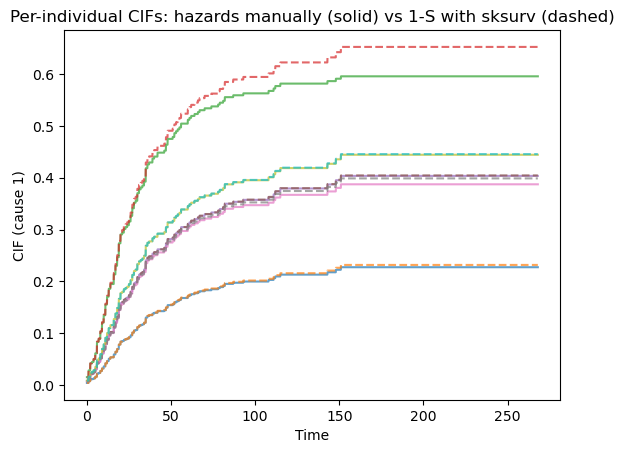

Absolute difference in CIF manual and CIF from sksurv function 0.6290967193069851
Fold 2 (Manual): IBS(cause1)=0.1968 | IBS(cause2)=0.1848


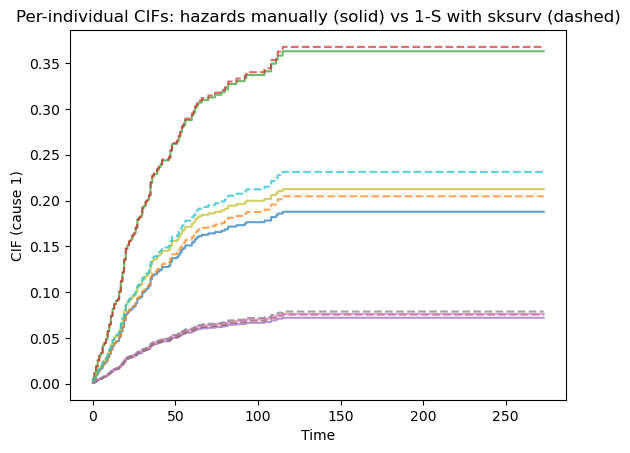

Absolute difference in CIF manual and CIF from sksurv function 0.3343945274939738
Fold 3 (Manual): IBS(cause1)=0.1770 | IBS(cause2)=0.1693


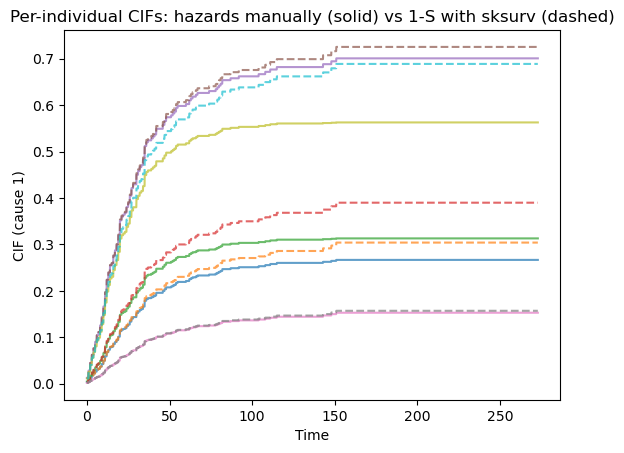

Absolute difference in CIF manual and CIF from sksurv function 0.39637886074939005
Fold 4 (Manual): IBS(cause1)=0.2139 | IBS(cause2)=0.1646


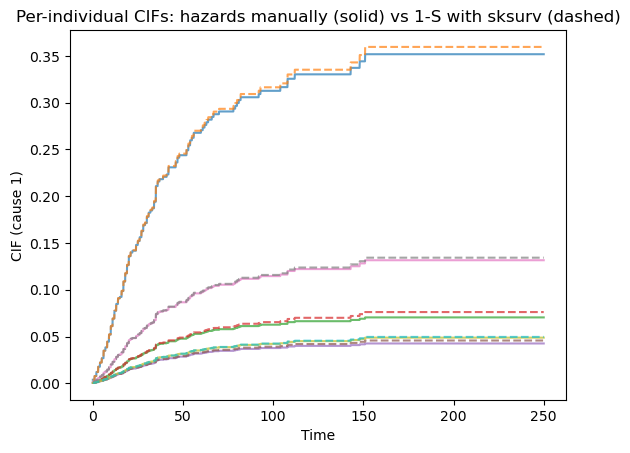

Absolute difference in CIF manual and CIF from sksurv function 0.23197092853872736
Fold 5 (Manual): IBS(cause1)=0.2130 | IBS(cause2)=0.2015


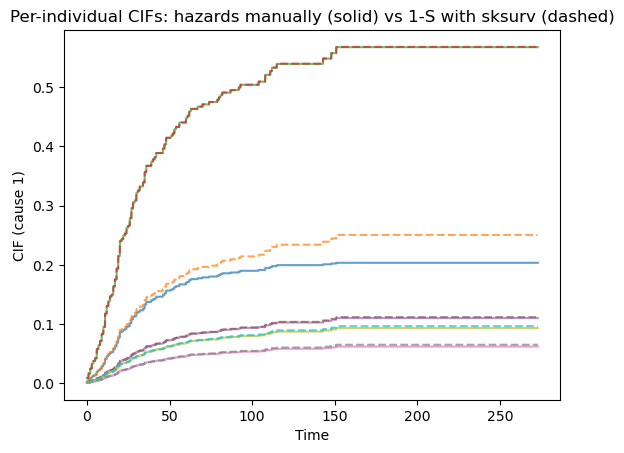

Absolute difference in CIF manual and CIF from sksurv function 0.6262019887790874


In [239]:
ibs_c1_folds, ibs_c2_folds = [], []

base_pre = build_preprocessor(X)  

for fold, (train_idx, val_idx) in enumerate(splits, 1):
    
    #print(f"\nFold {fold}")

    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    t_train, t_val = T_all[train_idx].astype(float), T_all[val_idx].astype(float)
    d_train, d_val = D_all[train_idx].astype(int),   D_all[val_idx].astype(int)

    time_grid = np.arange(0, np.max(t_train), 0.1)

    y_c1 = Surv.from_arrays(event=(d_train == 1), time=t_train)
    y_c2 = Surv.from_arrays(event=(d_train == 2), time=t_train)

    # cloning the pipe
    pre = clone(base_pre).fit(X_train)

    Xtr = pre.transform(X_train)
    Xva = pre.transform(X_val)

    # adding alpha as regularizer for ridge regression penalty
    cox_1 = CoxPHSurvivalAnalysis(alpha=1.0).fit(Xtr, y_c1)
    cox_2 = CoxPHSurvivalAnalysis(alpha=1.0).fit(Xtr, y_c2)

    # 6) Estimate the cumulative hazard
    m = len(time_grid)
    A1 = cox_1.predict_cumulative_hazard_function(Xva)
    A2 = cox_2.predict_cumulative_hazard_function(Xva)

    # 7) Calculate G_t
    metrics = CompRiskMetricsCompute(
        time_grid=time_grid,
        durations_train=t_train,
        delta_train=d_train,
        eps=0.01
    )
    # To avoid weights blowing up:
    mask = metrics.G_t >= 0.05
    time_grid = time_grid[mask]

    # re-init with trimmed grid
    metrics = CompRiskMetricsCompute(time_grid=time_grid, 
                                     durations_train=t_train, 
                                     delta_train=d_train, 
                                     eps=0.01)
    
    # make it as matrix
    A1_mat = chf_to_matrix(A1, time_grid)   # shape (n_val, m)
    A2_mat = chf_to_matrix(A2, time_grid)

    # 8.1) Calculate the CIFs from the hazards
    F1_pred, F2_pred = cifs_from_cs_hazards(A1_mat, A2_mat)

    # 8.2) We might be able to calculate directly 
    S1_pred = cox_1.predict_survival_function(Xva)
    S2_pred = cox_2.predict_survival_function(Xva)

    S_mat1  = fns_to_matrix(S1_pred, time_grid)        # (n_val, len(time_grid))
    F1_pred_direct = 1.0 - S_mat1

    S_mat2  = fns_to_matrix(S2_pred, time_grid)        # (n_val, len(time_grid))
    F2_pred_direct = 1.0 - S_mat2

    # 9) Calculate the metrics
    ibs_c1 = metrics.integrated_brier_cif(F1_pred, t_val, d_val, cause=1)
    ibs_c2 = metrics.integrated_brier_cif(F2_pred, t_val, d_val, cause=2)

    ibs_c1_folds.append(float(ibs_c1))
    ibs_c2_folds.append(float(ibs_c2))
    print(f"Fold {fold} (Manual): IBS(cause1)={ibs_c1:.4f} | IBS(cause2)={ibs_c2:.4f}")

    # a few individuals
    idx = np.arange(min(5, F1_pred.shape[0]))
    plt.figure()
    for i in idx:
        plt.plot(time_grid, F1_pred[i], alpha=0.7)
        plt.plot(time_grid, F1_pred_direct[i], ls="--", alpha=0.7)
    plt.xlabel("Time"); plt.ylabel("CIF (cause 1)")
    plt.title("Per-individual CIFs: hazards manually (solid) vs 1-S with sksurv (dashed)")
    plt.show()


    max_abs_diff = np.max(np.abs(F1_pred - F1_pred_direct))
    print(f"Absolute difference in CIF manual and CIF from sksurv function {max_abs_diff}")





So far ew have done some technical checks. There is less survival analysis functions built in python libraries, so it was necesary to implement some of them. After doing so: 

1. We get the same results (and conclusions) calculating the IBS using our manual functions vs Albergue et at 2025 (in hazardous github). Quite low IBS, which is a good thing. 

2. We get the same IBS using manual set up of preprocessing vs using Pipes from sksurv.

3. CIFs calculated from CoxPH with built in function (1- predict_survival function) vs using manual function give in some cases different results

Let's focus on adding another model... and looking into shap values. 

#### Explainability

Something very useful would be to use the shap values. It would be great to see how they vary across time SurvShap does that exactly. It might be useful with tree models.

However, in the case of linear model such CoxPH might not be necessary ... but we can look at it.
The baseline input is like the training mean of each feature ($\mu$). And for a linear model:

$$(\phi)_{ij} = (x_{ij} - \mu_{j}) \beta_j$$

So, basically SHAP equals to the coeficient ($\beta$) multiplied by the centered feature. Where each entry $(\phi)_{ij}$ is the contribution of feature j in the sample i to the linear predictor. 

We can then agregate the global inportance, as the mean absolute SHAP across the validation samples, per feature.

In [260]:

def shap_linear_val(Xtr_z, Xva_z, beta, feat_names):
    mu  = Xtr_z.mean(axis=0) 
    phi = (Xva_z - mu) * beta # (xij - muj) * betaj
    return pd.Series(np.mean(np.abs(phi), axis=0), index=feat_names)


In [261]:
def roots_from_ct(pre):
    ct = pre.named_steps["pre"]
    num_roots = []
    cat_roots = []
    for name, trans, cols in ct.transformers_:
        cols = list(cols) if hasattr(cols, "__iter__") and not isinstance(cols, str) else [cols]
        if name == "num": num_roots = cols
        if name == "cat": cat_roots = cols
    return set(num_roots), set(cat_roots)

def group_ohe(gimp, cat_roots, num_roots):
    out = {}
    for name, v in gimp.items():
        base = name.split("=")[0] if "=" in name else name
        root = base if (base in num_roots or base in cat_roots) else \
               next((r for r in cat_roots if base.startswith(r+"_") or base.startswith(r+"=")), base)
        out[root] = out.get(root, 0.0) + float(v)
    return pd.Series(out).sort_values(ascending=False)

In [262]:
len(X.columns)

81

In [255]:
ibs_c1_folds, ibs_c2_folds = [], []
gimp_c1_folds, gimp_c2_folds = [], []
n_val_per_fold = []

base_pre = build_preprocessor(X)  

for fold, (train_idx, val_idx) in enumerate(splits, 1):
    
    #print(f"\nFold {fold}")

    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    t_train, t_val = T_all[train_idx].astype(float), T_all[val_idx].astype(float)
    d_train, d_val = D_all[train_idx].astype(int),   D_all[val_idx].astype(int)

    y_c1 = Surv.from_arrays(event=(d_train == 1), time=t_train)
    y_c2 = Surv.from_arrays(event=(d_train == 2), time=t_train)

    # cloning the pipe
    pre = clone(base_pre).fit(X_train)

    Xtr = pre.transform(X_train)
    Xva = pre.transform(X_val)

    # adding alpha as regularizer for ridge regression penalty
    cox_1 = CoxPHSurvivalAnalysis(alpha=1.0).fit(Xtr, y_c1)
    cox_2 = CoxPHSurvivalAnalysis(alpha=1.0).fit(Xtr, y_c2)
    
    # getting columns names
    names = pre.named_steps["pre"].get_feature_names_out()
    mask  = pre.named_steps["nzv"].get_support()
    feat_names = np.asarray(names)[mask]
    #print(feat_names)

    # to regroup one-hot into cat
    num_roots, cat_roots = roots_from_ct(pre)

    gimp_c1 = shap_linear_val(Xtr, Xva, cox_1.coef_, feat_names)
    gimp_c2 = shap_linear_val(Xtr, Xva, cox_2.coef_, feat_names)

    gimp_c1_folds.append(group_ohe(gimp_c1, cat_roots, num_roots))
    gimp_c2_folds.append(group_ohe(gimp_c2, cat_roots, num_roots))
    n_val_per_fold.append(len(X_val))



In [263]:
def aggregate_importance(imp_series_list, n_val_per_fold):
    feats = sorted(set().union(*[s.index for s in imp_series_list]))
    M = pd.DataFrame({i: s.reindex(feats).fillna(0.0) for i, s in enumerate(imp_series_list)}, index=feats)
    w = np.asarray(n_val_per_fold, float); w = w / w.sum()
    return M.dot(w).sort_values(ascending=False)

def plot_importance(imp, title, k=20):
    top = imp.head(k).iloc[::-1]
    plt.figure()
    plt.barh(top.index, top.values)
    plt.xlabel("Mean |SHAP| on risk score (OOF)")
    plt.title(title)
    plt.tight_layout(); plt.show()

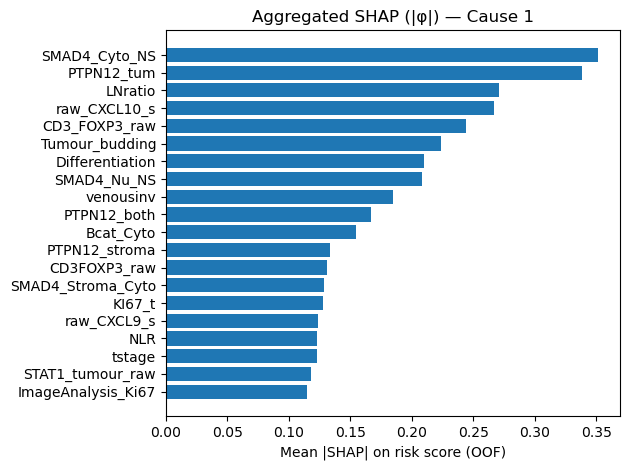

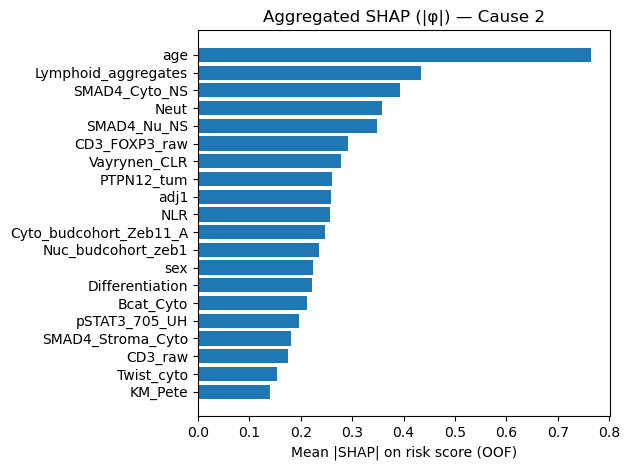

In [265]:
agg_c1 = aggregate_importance(gimp_c1_folds, n_val_per_fold)
agg_c2 = aggregate_importance(gimp_c2_folds, n_val_per_fold)

plot_importance(agg_c1, "Aggregated SHAP (|φ|) — Cause 1", k=20)
plot_importance(agg_c2, "Aggregated SHAP (|φ|) — Cause 2", k=20)


In [ ]:
# might be useful for other models with no PH and non-linear
from survshap import SurvivalModelExplainer, PredictSurvSHAP, ModelSurvSHAP
import shap

#### Compared with qpis

How much better better/worse are the predictions with just the qpis?


In [ ]:
qpis = [
    "MMR_Status_Jen","BRAF","sex","Location","Right0_Left1",
    "tstage","nstage","mstage","Differentiation","LNratio","MargInv",
    "DFS_months_2020","Cmprsk_Status", "age"
]

df_qpis = df.loc[X.index, qpis].copy()  

# Features / targets for the subset dataset
X_small = df_qpis.drop(columns=["DFS_months_2020", "Cmprsk_Status"])
T_small = df_qpis["DFS_months_2020"].to_numpy(float)
D_small = df_qpis["Cmprsk_Status"].to_numpy(int)


In [ ]:
len(X_small.columns)

In [ ]:
### maybe just in function

def run_cv_ibs(X_df, T_all, D_all, splits, base_pre,
               epsG=0.01, Gmin=0.05, alpha=1.0):
    ibs_c1, ibs_c2, n_val = [], [], []

    for (train_idx, val_idx) in splits:
        X_train, X_val = X_df.iloc[train_idx], X_df.iloc[val_idx]
        t_train, t_val = T_all[train_idx].astype(float), T_all[val_idx].astype(float)
        d_train, d_val = D_all[train_idx].astype(int),   D_all[val_idx].astype(int)

        # preprocessor
        pre = clone(base_pre).fit(X_train)
        Xtr, Xva = pre.transform(X_train), pre.transform(X_val)

        # cause-specific Cox
        y_c1 = Surv.from_arrays(event=(d_train==1), time=t_train)
        y_c2 = Surv.from_arrays(event=(d_train==2), time=t_train)
        cox_1 = CoxPHSurvivalAnalysis(alpha=alpha).fit(Xtr, y_c1)
        cox_2 = CoxPHSurvivalAnalysis(alpha=alpha).fit(Xtr, y_c2)

        # 6) Estimate the cumulative hazard
        A1 = cox_1.predict_cumulative_hazard_function(Xva)
        A2 = cox_2.predict_cumulative_hazard_function(Xva)

        t_event_max = np.max(t_train[d_train != 0]) if np.any(d_train != 0) else np.max(t_train)
        raw_grid = np.arange(0.0, max(t_event_max, 1e-8), 0.1)

        probe = CompRiskMetricsCompute(time_grid=raw_grid, durations_train=t_train, delta_train=d_train, eps=0.01)
        mask = probe.G_t >= 0.05
        time_grid = raw_grid[mask] if np.any(mask) else raw_grid[:min(10, raw_grid.size)]
        metrics = CompRiskMetricsCompute(time_grid=time_grid, durations_train=t_train, delta_train=d_train, eps=0.01)

        # CIFs
        A1_mat = chf_to_matrix(A1, time_grid)
        A2_mat = chf_to_matrix(A2, time_grid)
        F1_pred, F2_pred = cifs_from_cs_hazards(A1_mat, A2_mat)

        # IBS per cause
        ibs1 = metrics.integrated_brier_cif(F1_pred, t_val, d_val, cause=1)
        ibs2 = metrics.integrated_brier_cif(F2_pred, t_val, d_val, cause=2)

        ibs_c1.append(float(ibs1)); ibs_c2.append(float(ibs2))
        n_val.append(len(X_val))

    return np.array(ibs_c1), np.array(ibs_c2), np.array(n_val)


In [ ]:
ibs_c1_folds, ibs_c2_folds = [], []
ibs_c1_folds_small, ibs_c2_folds_small = [], []

base_pre = build_preprocessor(X)  
base_pre_small = build_preprocessor(X_small) 


ibs1_full, ibs2_full, nval_full = run_cv_ibs(X,        
                                             T_all,  
                                             D_all,  
                                             splits, 
                                             base_pre,
                                             alpha=1)

ibs1_sub,  ibs2_sub,  nval_sub  = run_cv_ibs(X_small,  
                                             T_small, 
                                             D_small, 
                                             splits, 
                                             base_pre_small,
                                             alpha=1)



In [ ]:
ibs1_full

In [ ]:
ibs1_sub

Suggests that in all cases the IBS is better with the small dataset. 

In [ ]:
np.mean(ibs1_sub) - np.mean(ibs1_full)


In [ ]:
np.mean(ibs2_sub) - np.mean(ibs2_full)


In [ ]:
np.mean(ibs1_full)

In [ ]:
np.mean(ibs1_sub)

In [ ]:
ibs_c1_folds, ibs_c2_folds = [], []
gimp_c1_folds, gimp_c2_folds = [], []
n_val_per_fold = []

base_pre = build_preprocessor(X_small)  

for fold, (train_idx, val_idx) in enumerate(splits, 1):

    X_train, X_val = X_small.iloc[train_idx].copy(), X_small.iloc[val_idx].copy()
    t_train, t_val = T_small[train_idx].astype(float), T_small[val_idx].astype(float)   # if labels differ, use T_small/D_small
    d_train, d_val = D_small[train_idx].astype(int),   D_small[val_idx].astype(int)

    pre = clone(base_pre).fit(X_train)
    Xtr = pre.transform(X_train)
    Xva = pre.transform(X_val)

    y_c1 = Surv.from_arrays(event=(d_train == 1), time=t_train)
    y_c2 = Surv.from_arrays(event=(d_train == 2), time=t_train)
    cox1 = CoxPHSurvivalAnalysis(alpha=1.0).fit(Xtr, y_c1)
    cox2 = CoxPHSurvivalAnalysis(alpha=1.0).fit(Xtr, y_c2)

    t_event_max = np.max(t_train[d_train != 0]) if np.any(d_train != 0) else np.max(t_train)
    raw_grid = np.arange(0.0, max(t_event_max, 1e-8), 0.1)

    probe = CompRiskMetricsCompute(time_grid=raw_grid, durations_train=t_train, delta_train=d_train, eps=0.01)
    mask = probe.G_t >= 0.05
    time_grid = raw_grid[mask] if np.any(mask) else raw_grid[:min(10, raw_grid.size)]
    metrics = CompRiskMetricsCompute(time_grid=time_grid, durations_train=t_train, delta_train=d_train, eps=0.01)

    A1 = cox1.predict_cumulative_hazard_function(Xva)
    A2 = cox2.predict_cumulative_hazard_function(Xva)
    A1_mat = chf_to_matrix(A1, time_grid)
    A2_mat = chf_to_matrix(A2, time_grid)
    F1_pred, F2_pred = cifs_from_cs_hazards(A1_mat, A2_mat)

    ibs_c1 = metrics.integrated_brier_cif(F1_pred, t_val, d_val, cause=1)
    ibs_c2 = metrics.integrated_brier_cif(F2_pred, t_val, d_val, cause=2)
    ibs_c1_folds.append(float(ibs_c1))
    ibs_c2_folds.append(float(ibs_c2))

    names_all = pre.named_steps["pre"].get_feature_names_out()
    kept_mask = pre.named_steps["nzv"].get_support()
    feat_names = np.asarray(names_all)[kept_mask]
    num_roots, cat_roots = roots_from_ct(pre)

    gimp_c1 = shap_linear_val(Xtr, Xva, cox1.coef_, feat_names)
    gimp_c2 = shap_linear_val(Xtr, Xva, cox2.coef_, feat_names)
    gimp_c1_folds.append(group_ohe(gimp_c1, cat_roots, num_roots))
    gimp_c2_folds.append(group_ohe(gimp_c2, cat_roots, num_roots))

    n_val_per_fold.append(len(X_val))



In [ ]:
agg_c1 = aggregate_importance(gimp_c1_folds, n_val_per_fold)
agg_c2 = aggregate_importance(gimp_c2_folds, n_val_per_fold)

plot_importance(agg_c1, "Aggregated SHAP (|φ|) — Cause 1", k=20)
plot_importance(agg_c2, "Aggregated SHAP (|φ|) — Cause 2", k=20)

### why these results... 

1. Lots of covariates in the bigger dataset, collinearity ? Sparsity?

2. Might be some problematic imputation?

3. Maybe try permutation to see which variables are hurting? 

4. Maybe some inner fold to determine the hyperparameter alpha in ridge cox ph 